# Intelligent Agents: Reflex-Based Agents for the Vacuum-cleaner World

Student Name: Travis N. Pryor

I have used the following AI tools: Cursor, Gemini, ChatGPT, Copilot

I understand that my submission needs to be my own work: TNP

## Learning Outcomes

* Design and build a simulation environment that models sensor inputs, actuator effects, and performance measurement.
* Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
* Practice how the environment and the agent function interact.
* Analyze agent performance through controlled experiments across different environment configurations.
* Graduate Students: Develop strategies for handling uncertainty and imperfect information in autonomous agent systems.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.

### AI Use

Here are some guidelines that will make it easier for you:

* __Don't:__ Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
* __Don't:__ Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
* __Do:__ Use AI for debugging and letting it explain code and concepts from class.

### Using Visual Studio Code

If you use VS code then you can use `Export` (click on `...` in the menu bar) to save your notebook as a HTML file. Note that you have to run all blocks before so the HTML file contains your output.

### Using Google Colab

In Colab you need to save the notebook on GoogleDrive to work with it. For this you need to mount your google dive and change to the correct directory by uncommenting the following lines and running the code block.

In [2]:
# from google.colab import drive
# import os
#
# drive.mount('/content/drive')
# os.chdir('/content/drive/My Drive/Colab Notebooks/')

Once you are done with the assignment and have run all code blocks using `Runtime/Run all`, you can convert the file on your GoogleDrive into HTML be uncommenting the following line and running the block.

In [3]:
# %jupyter nbconvert --to html Copy\ of\ robot_vacuum.ipynb

You may have to fix the file location or the file name to match how it looks on your GoogleDrive. You can navigate in Colab to your GoogleDrive using the little folder symbol in the navigation bar to the left.

## Introduction

In this assignment you will implement a simulator environment for an automatic vacuum cleaner robot, a set of different reflex-based agent programs, and perform a comparison study for cleaning a single room. Focus on the __cleaning phase__ which starts when the robot is activated and ends when the last dirty square in the room has been cleaned. Someone else will take care of the agent program needed to navigate back to the charging station after the room is clean.

## PEAS description of the cleaning phase

__Performance Measure:__ Each action costs 1 energy unit. The performance is measured as the sum of the energy units used to clean the whole room.

__Environment:__ A room with $n \times n$ squares where $n = 5$. Dirt is randomly placed on each square with probability $p = 0.2$. For simplicity, you can assume that the agent knows the size and the layout of the room (i.e., it knows $n$). To start, the agent is placed on a random square.

__Actuators:__ The agent can clean the current square (action `suck`) or move to an adjacent square by going `north`, `east`, `south`, or `west`.

__Sensors:__ Four bumper sensors, one for north, east, south, and west; a dirt sensor reporting dirt in the current square.  


## The agent program for a simple randomized agent

The agent program is a function that gets sensor information (the current percepts) as the arguments. The arguments are:

* A dictionary with boolean entries for the for bumper sensors `north`, `east`, `west`, `south`. E.g., if the agent is on the north-west corner, `bumpers` will be `{"north" : True, "east" : False, "south" : False, "west" : True}`.
* The dirt sensor produces a boolean.

The agent returns the chosen action as a string.

Here is an example implementation for the agent program of a simple randomized agent:  

In [4]:
# make sure numpy is installed
%pip install -q numpy

In [5]:
import numpy as np

actions = ["north", "east", "west", "south", "suck"]

def simple_randomized_agent(bumpers, dirty):
    return np.random.choice(actions)

In [6]:
# define percepts (current location is NW corner and it is dirty)
bumpers = {"north" : True, "east" : False, "south" : False, "west" : True}
dirty = True

# call agent program function with percepts and it returns an action
simple_randomized_agent(bumpers, dirty)

np.str_('west')

__Note:__ This is not a rational intelligent agent. It ignores its sensors and may bump into a wall repeatedly or not clean a dirty square. You will be asked to implement rational agents below.

## Simple environment example

We implement a simple simulation environment that supplies the agent with its percepts.
The simple environment is infinite in size (bumpers are always `False`) and every square is always dirty, even if the agent cleans it. The environment function returns a different performance measure than the one specified in the PEAS description! Since the room is infinite and all squares are constantly dirty, the agent can never clean the whole room. Your implementation needs to implement the **correct performance measure.** The energy budget of the agent is specified as `max_steps`.

In [7]:
def simple_environment(agent_function, max_steps, verbose = True):
    num_cleaned = 0

    for i in range(max_steps):
        dirty = True
        bumpers = {"north" : False, "south" : False, "west" : False, "east" : False}

        action = agent_function(bumpers, dirty)
        if (verbose): print("step", i , "- action:", action)

        if (action == "suck"):
            num_cleaned = num_cleaned + 1

    return num_cleaned



Do one simulation run with a simple randomized agent that has enough energy for 20 steps.

In [8]:
simple_environment(simple_randomized_agent, max_steps = 20)

step 0 - action: west
step 1 - action: west
step 2 - action: west
step 3 - action: north
step 4 - action: north
step 5 - action: north
step 6 - action: north
step 7 - action: north
step 8 - action: east
step 9 - action: suck
step 10 - action: west
step 11 - action: suck
step 12 - action: south
step 13 - action: south
step 14 - action: suck
step 15 - action: north
step 16 - action: suck
step 17 - action: south
step 18 - action: suck
step 19 - action: north


5

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.


## Task 1: Implement a simulation environment [20 Points]

The simple environment above is not very realistic. Your environment simulator needs to follow the PEAS description from above. It needs to:

* Initialize the environment by storing the state of each square (clean/dirty) and making some dirty. ([Help with random numbers and arrays in Python](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/random_numbers_and_arrays.ipynb))
* Keep track of the agent's position.
* Call the agent function repeatedly and provide the agent function with the sensor inputs.  
* React to the agent's actions. E.g, by removing dirt from a square or moving the agent around unless there is a wall in the way.
* Keep track of the performance measure. That is, track the agent's actions until all dirty squares are clean and count the number of actions it takes the agent to complete the task.

The easiest implementation for the environment is to hold an 2-dimensional array to represent if squares are clean or dirty and to call the agent function in a loop until all squares are clean or a predefined number of steps have been reached (i.e., the robot runs out of energy).

The simulation environment should be a function like the `simple_environment()` and needs to work with the simple randomized agent program from above. **Use the same environment for all your agent implementations in the tasks below.**

*Note on debugging:* Debugging is difficult. Make sure your environment prints enough information when you use `verbose = True`. Also, implementing a function that the environment can use to displays the room with dirt and the current position of the robot at every step is very useful.  

In [9]:
# Vacuum World environment using the PEAS method and a simple randomized agent

from typing import Callable, Dict, Tuple, List, Any
import numpy as np
import math

Action = str  # "Up","Down","Left","Right","Suck","NoOp"
Percept = Dict[str, Any]

def init_grid(rows: int, cols: int, dirt_prob: float = 0.3, seed: int = None):
    # True = dirty, False = clean
    rng = np.random.default_rng(seed)
    return rng.random((rows, cols)) < dirt_prob

def walls_for_pos(pos: Tuple[int, int], rows: int, cols: int) -> Dict[str, bool]:
    r, c = pos
    return {
        "up":    (r == 0),
        "down":  (r == rows - 1),
        "left":  (c == 0),
        "right": (c == cols - 1),
    }

def ascii_grid(grid, agent_pos: Tuple[int, int]) -> str:
    # ASCII map: '*' dirty, '.' clean, 'A' agent
    rows, cols = grid.shape
    lines = []
    for r in range(rows):
        row_chars = []
        for c in range(cols):
            ch = '*' if grid[r, c] else '.'
            if (r, c) == agent_pos:
                ch = 'A'
            row_chars.append(ch)
        lines.append(' '.join(row_chars))
    return '\n'.join(lines)

def simulate_environment(
    agent_fn: Callable[[Percept], Action],
    rows: int = 2,
    cols: int = 3,
    dirt_prob: float = 0.4,
    max_steps: int = 500,
    start_pos: Tuple[int, int] = (0, 0),
    seed: int = None,
    verbose: bool = False,
) -> Dict[str, Any]:
    grid = init_grid(rows, cols, dirt_prob=dirt_prob, seed=seed)
    initial_dirty = int(grid.sum())
    agent_pos = start_pos
    steps = 0
    actions: List[str] = []
    trajectory: List[Tuple[int, int]] = [agent_pos]

    if verbose:
        print("Initial grid (A=agent, *=dirty, .=clean):")
        print(ascii_grid(grid, agent_pos))
        print(f"Initial dirty squares: {initial_dirty}")
        print("-" * 40)

    while steps < max_steps:
        if grid.sum() == 0:
            break

        # Builds percept
        w = walls_for_pos(agent_pos, rows, cols)
        percept: Percept = {
            "dirty": bool(grid[agent_pos]),
            "pos": agent_pos,
            "walls": w,
        }

        action: Action = agent_fn(percept)
        actions.append(action)

        # Apply action
        r, c = agent_pos
        if action == "Suck":
            grid[r, c] = False
        elif action == "Up" and not w["up"]:
            agent_pos = (r - 1, c)
        elif action == "Down" and not w["down"]:
            agent_pos = (r + 1, c)
        elif action == "Left" and not w["left"]:
            agent_pos = (r, c - 1)
        elif action == "Right" and not w["right"]:
            agent_pos = (r, c + 1)

        steps += 1
        trajectory.append(agent_pos)

        if verbose:
            print(f"Step {steps}: action={action}, pos={agent_pos}, dirty_here={grid[agent_pos]}")
            print(ascii_grid(grid, agent_pos))
            print("-" * 40)

    success = (grid.sum() == 0)
    return {
        "success": success,
        "steps": steps,
        "initial_dirty": initial_dirty,
        "final_dirty": int(grid.sum()),
        "trajectory": trajectory,
        "actions": actions,
        "grid": grid,
    }

def randomized_reflex_agent(percept: Percept) -> Action:
    # Suck if dirty, else move randomly among legal moves
    if percept["dirty"]:
        return "Suck"
    w = percept["walls"]
    moves: List[Action] = []
    if not w["up"]:
        moves.append("Up")
    if not w["down"]:
        moves.append("Down")
    if not w["left"]:
        moves.append("Left")
    if not w["right"]:
        moves.append("Right")
    if not moves:
        return "NoOp"
    rng = np.random.default_rng()
    return moves[int(rng.integers(0, len(moves)))]


Show that your environment works with the simple randomized agent from above.

In [10]:
# Showing examples of the enviroment working
res = simulate_environment(
    randomized_reflex_agent,
    rows=2, cols=3,
    dirt_prob=0.5,
    max_steps=100,
    seed=8,
    verbose=True
)

print("\nSingle Episode Summary")
print("Success:", bool(res["success"]))
print("Steps:", res["steps"])
print("Dirty (initial -> final):", res["initial_dirty"], "->", res["final_dirty"])

# Checks
import numpy as np
assert isinstance(res["success"], (bool, np.bool_))
assert isinstance(res["steps"], (int, np.integer)) and res["steps"] >= 0
assert len(res["actions"]) == res["steps"]
assert len(res["trajectory"]) == res["steps"] + 1


# Runs multiple trials
def run_experiments_no_plot(
    agent_fn: Callable[[Percept], Action],
    trials: int = 20,
    rows: int = 3,
    cols: int = 4,
    dirt_prob: float = 0.45,
    max_steps: int = 300
):
    steps_list: List[int] = []
    successes: List[bool] = []
    for t in range(trials):
        out = simulate_environment(
            agent_fn,
            rows=rows,
            cols=cols,
            dirt_prob=dirt_prob,
            max_steps=max_steps,
            start_pos=(0, 0),
            seed=t,
            verbose=False
        )
        steps_list.append(out["steps"])
        successes.append(out["success"])

    success_rate = sum(successes) / trials
    successful_steps = [s for s, ok in zip(steps_list, successes) if ok]
    avg_steps = (sum(successful_steps) / len(successful_steps)) if successful_steps else math.nan

    return {
        "steps_list": steps_list,
        "success_rate": success_rate,
        "avg_steps_on_success": avg_steps
    }


# Run experiment funciton by setting up the enivroment
summary = run_experiments_no_plot(
    randomized_reflex_agent,
    trials=20,
    rows=3,
    cols=4,
    dirt_prob=0.45,
    max_steps=300
)

print("\nMulti-Trial Summary")
print("Success rate:", summary["success_rate"])
print("Avg steps (successes):", summary["avg_steps_on_success"])
print("Steps list:", summary["steps_list"])


Initial grid (A=agent, *=dirty, .=clean):
A . *
. . *
Initial dirty squares: 3
----------------------------------------
Step 1: action=Suck, pos=(0, 0), dirty_here=False
A . *
. . *
----------------------------------------
Step 2: action=Right, pos=(0, 1), dirty_here=False
. A *
. . *
----------------------------------------
Step 3: action=Down, pos=(1, 1), dirty_here=False
. . *
. A *
----------------------------------------
Step 4: action=Right, pos=(1, 2), dirty_here=True
. . *
. . A
----------------------------------------
Step 5: action=Suck, pos=(1, 2), dirty_here=False
. . *
. . A
----------------------------------------
Step 6: action=Up, pos=(0, 2), dirty_here=True
. . A
. . .
----------------------------------------
Step 7: action=Suck, pos=(0, 2), dirty_here=False
. . A
. . .
----------------------------------------

Single Episode Summary
Success: True
Steps: 7
Dirty (initial -> final): 3 -> 0

Multi-Trial Summary
Success rate: 1.0
Avg steps (successes): 52.45
Steps list: [

## Task 2:  Implement a simple reflex agent [10 Points]

The simple reflex agent randomly walks around but reacts to the bumper sensor by not bumping into the wall and to dirt with sucking. Implement the agent program as a function.

_Note:_ Agents cannot directly use variable in the environment. They only gets the percepts as the arguments to the agent function. Use the function signature for the `simple_randomized_agent` function above.

In [11]:
def simple_reflex_agent(percept):
    """
    Simple Reflex Agent:
    - Sucks if the current square is dirty
    - Otherwise, randomly chooses a legal move (avoiding walls)
    """
    if percept["dirty"]:
        return "Suck"

    w = percept["walls"]
    legal_moves = []
    if not w["up"]:
        legal_moves.append("Up")
    if not w["down"]:
        legal_moves.append("Down")
    if not w["left"]:
        legal_moves.append("Left")
    if not w["right"]:
        legal_moves.append("Right")

    if not legal_moves:
        return "NoOp"

    rng = np.random.default_rng()
    return legal_moves[int(rng.integers(0, len(legal_moves)))]

Show how the agent works with your environment.

In [12]:
res = simulate_environment(
    simple_reflex_agent,
    rows=3, cols=3,
    dirt_prob=0.5,
    max_steps=50,
    seed=1,
    verbose=True
)

print("Simple Reflex Agent Test")
print("Success:", res["success"])
print("Steps:", res["steps"])
print("Initial dirty:", res["initial_dirty"])
print("Final dirty:", res["final_dirty"])


Initial grid (A=agent, *=dirty, .=clean):
A . *
. * *
. * .
Initial dirty squares: 4
----------------------------------------
Step 1: action=Right, pos=(0, 1), dirty_here=False
. A *
. * *
. * .
----------------------------------------
Step 2: action=Right, pos=(0, 2), dirty_here=True
. . A
. * *
. * .
----------------------------------------
Step 3: action=Suck, pos=(0, 2), dirty_here=False
. . A
. * *
. * .
----------------------------------------
Step 4: action=Down, pos=(1, 2), dirty_here=True
. . .
. * A
. * .
----------------------------------------
Step 5: action=Suck, pos=(1, 2), dirty_here=False
. . .
. * A
. * .
----------------------------------------
Step 6: action=Down, pos=(2, 2), dirty_here=False
. . .
. * .
. * A
----------------------------------------
Step 7: action=Left, pos=(2, 1), dirty_here=True
. . .
. * .
. A .
----------------------------------------
Step 8: action=Suck, pos=(2, 1), dirty_here=False
. . .
. * .
. A .
----------------------------------------
Ste

## Task 3: Implement a model-based reflex agent [20 Points]

Model-based agents use a state to keep track of what they have done and perceived so far. Your agent needs to find out where it is located and then keep track of its current location. You also need a set of rules based on the state and the percepts to make sure that the agent will clean the whole room. For example, the agent can move to a corner to determine its location and then it can navigate through the whole room and clean dirty squares.

Describe how you define the __agent state__ and how your agent works before implementing it. ([Help with implementing state information on Python](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/store_agent_state_information.ipynb))

In [14]:
#This agent keeps track of a small internal state with two parts:
#phase: tells if the agent is still moving to the top-left corner ("to_corner") or if it has started sweeping the room ("sweep").
#dir: remembers the current horizontal direction ("right" or "left") for the sweeping pattern.
#The agent first moves up and left until it reaches the top-left corner. If the current square is dirty, it sucks. After that, it sweeps row by row in a serpentine pattern: moving across the row, going down one row at the edge, then reversing direction. If it reaches the bottom and cannot move further, it stops.

In [15]:
def make_model_reflex_agent():
    """
    Returns agent function with the internal state.
    """
    state = {
        "phase": "to_corner",
        "dir": "right",
    }

    def agent(percept):
        # If current square is dirty, clean it first
        if percept["dirty"]:
            return "Suck"

        w = percept["walls"]

        # Go to top-left corner to localize
        if state["phase"] == "to_corner":
            if not w["up"]:
                return "Up"
            if not w["left"]:
                return "Left"
            state["phase"] = "sweep"
            state["dir"] = "right"

        # sweep
        if state["dir"] == "right":
            # Keep moving right if possible
            if not w["right"]:
                return "Right"
            if not w["down"]:
                state["dir"] = "left"
                return "Down"
            return "NoOp"

        else:
            # Keep moving left if possible
            if not w["left"]:
                return "Left"
            if not w["down"]:
                state["dir"] = "right"
                return "Down"
            return "NoOp"

    return agent


Show how the agent works with your environment.

---



In [16]:
model_agent = make_model_reflex_agent()
res = simulate_environment(
    model_agent,
    rows=3, cols=5,
    dirt_prob=0.5,
    max_steps=300,
    seed=21,
    verbose=True
)

print("Model-Based Agent: Single Episode Summary")
print("Success:", res["success"])
print("Steps:", res["steps"])
print("Dirty (initial -> final):", res["initial_dirty"], "->", res["final_dirty"])


Initial grid (A=agent, *=dirty, .=clean):
A . . * .
. * * . .
* . . * .
Initial dirty squares: 5
----------------------------------------
Step 1: action=Right, pos=(0, 1), dirty_here=False
. A . * .
. * * . .
* . . * .
----------------------------------------
Step 2: action=Right, pos=(0, 2), dirty_here=False
. . A * .
. * * . .
* . . * .
----------------------------------------
Step 3: action=Right, pos=(0, 3), dirty_here=True
. . . A .
. * * . .
* . . * .
----------------------------------------
Step 4: action=Suck, pos=(0, 3), dirty_here=False
. . . A .
. * * . .
* . . * .
----------------------------------------
Step 5: action=Right, pos=(0, 4), dirty_here=False
. . . . A
. * * . .
* . . * .
----------------------------------------
Step 6: action=Down, pos=(1, 4), dirty_here=False
. . . . .
. * * . A
* . . * .
----------------------------------------
Step 7: action=Left, pos=(1, 3), dirty_here=False
. . . . .
. * * A .
* . . * .
----------------------------------------
Step 8: acti

## Task 4: Simulation study [30 Points]

Compare the performance (the performance measure is defined in the PEAS description above) of the agents using  environments of different size. Do at least $5 \times 5$, $10 \times 10$ and
$100 \times 100$. Use 100 random runs for each. Present the results using tables and graphs. Discuss the differences between the agents.
([Help with charts and tables in Python](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/charts_and_tables.ipynb))

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def run_many(agent, trials=100, rows=5, cols=5, dirt_prob=0.5, max_steps=500, stateful=False):
    steps = []
    for t in range(trials):
        a = agent() if stateful else agent
        out = simulate_environment(
            a,
            rows=rows,
            cols=cols,
            dirt_prob=dirt_prob,
            max_steps=max_steps,
            start_pos=(0, 0),
            seed=t,
            verbose=False
        )
        steps.append(out["steps"])
    return np.mean(steps)


Fill out the following table with the average performance measure for 100 random runs (you may also create this table with code):

| Size     | Randomized Agent | Simple Reflex Agent | Model-based Reflex Agent |
|----------|------------------|---------------------|--------------------------|
| 5x5     | | | |
| 10x10   | | | |
| 100x100 | | | |

Add charts to compare the performance of the different agents.

      Size  Randomized Agent  Simple Reflex Agent  Model-based Reflex Agent
0      5x5            160.70               152.58                     35.41
1    10x10           1187.04              1159.06                    147.35
2  100x100           5000.00              5000.00                   5000.00


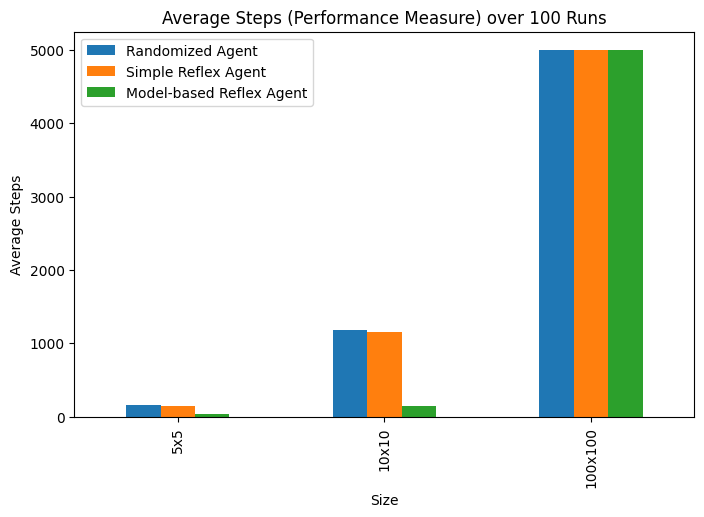

In [18]:
# Agents dictionary
agents = {
    "Randomized Agent": randomized_reflex_agent,
    "Simple Reflex Agent": simple_reflex_agent,
    "Model-based Reflex Agent": make_model_reflex_agent,
}

sizes = [(5, 5), (10, 10), (100, 100)]

results = []
for (r, c) in sizes:
    row = {"Size": f"{r}x{c}"}
    for name, ag in agents.items():
        avg_steps = run_many(
            ag,
            trials=100,
            rows=r,
            cols=c,
            max_steps=5000,
            stateful=(name=="Model-based Reflex Agent")
        )
        row[name] = avg_steps
    results.append(row)

df = pd.DataFrame(results)
print(df)

# Plot comparisons (bar chart)
df.set_index("Size").plot(kind="bar", figsize=(8,5))
plt.title("Average Steps (Performance Measure) over 100 Runs")
plt.ylabel("Average Steps")
plt.show()


## Task 5: Robustness of the agent implementations [10 Points]

Describe how **your agent implementations** will perform

* if it is put into a rectangular room with unknown size,
* if the cleaning area can have an irregular shape (e.g., a hallway connecting two rooms), or
* if the room contains obstacles (i.e., squares that it cannot pass through and trigger the bumper sensors).
* if the dirt sensor is not perfect and gives 10% of the time a wrong reading (clean when it is dirty or dirty when it is clean).
* if the bumper sensor is not perfect and 10% of the time does not report a wall when there is one.

In [19]:

#Rectangular room with unknown size
# Randomized and Simple Reflex: Both work without knowing size because they only react locally. They may wander and revisit cells often.
# Model-based Reflex: Also works; it first localizes (moves to top-left) then sweeps row by row, so it systematically covers the space.

#Irregular shapes
# Randomized and Simple Reflex: Still function because they follow local percepts, but paths are inefficient.
# Model-based Reflex: The serpentine plan assumes full rows. It still eventually covers most reachable cells, but may waste steps along uneven edges.

#Obstacles
# Randomized and Simple Reflex: Fine; they turn away when the bumper reports a wall.
# Model-based Reflex: Works if obstacles behave like walls. Coverage remains good but loses the perfect row by row property and will take more turns.

#Noisy dirt sensor
# Randomized and Simple Reflex: Can miss dirty tiles when false negatives occur. They have no memory, so they may leave dirt behind.
# Model-based Reflex: With a false clean reading, the agent would move on and may finish with leftover dirt. Needs an extra check such as confirming clean.

#Noisy bumper
# Randomized and Simple Reflex: May attempt illegal moves; the environment ignores them, wasting steps.
# Model-based Reflex: Similar waste. Because the sweep relies on edges, occasional missed bumper signals add some overhead, but coverage still happens since illegal moves are ignored.


## Advanced task: Imperfect Dirt Sensor

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

1. Change your simulation environment to run experiments for the following problem: The dirt sensor has a 10% chance of giving the wrong reading. Perform experiments to observe how this changes the performance of the three implementations. Your model-based reflex agent is likely not able to clean the whole room, so you need to measure performance differently as a tradeoff between energy cost and number of uncleaned squares.

2. Design an implement a solution for your model-based agent that will clean better. Show the improvement with experiments.

In [20]:
#Approach:
#1) Create a noisy simulation where only the **perceived** `dirty` bit is flipped with 10% probability. The true grid updates only on Suck.
#2) Run experiments for the three agents under noise and report: average steps, average final dirty, success rate, and composite score.
#3) Improve the model-based agent with a “confirm-clean” behavior: when entering a new cell, perform one Suck regardless of the reading to mitigate false negatives.
#4) Show improvement with experiments.

from typing import Callable, Dict, Any, Tuple, List
import numpy as np
import pandas as pd

def simulate_environment_noisy_dirt(
    agent_fn: Callable[[Dict[str, Any]], str],
    rows: int = 5,
    cols: int = 5,
    dirt_prob: float = 0.5,
    max_steps: int = 2000,
    start_pos: Tuple[int, int] = (0, 0),
    seed: int = None,
    verbose: bool = False,
    dirt_sensor_error: float = 0.10  # 10% chance
) -> Dict[str, Any]:

    rng = np.random.default_rng(seed)

    grid = (rng.random((rows, cols)) < dirt_prob)
    initial_dirty = int(grid.sum())

    pos = start_pos
    steps = 0
    actions: List[str] = []
    trajectory: List[Tuple[int, int]] = [pos]

    def walls_for_pos(p: Tuple[int, int]) -> Dict[str, bool]:
        r, c = p
        return {"up": r == 0, "down": r == rows - 1, "left": c == 0, "right": c == cols - 1}

    def ascii_grid(g, agent_pos):
        lines = []
        for r in range(rows):
            row_chars = []
            for c in range(cols):
                ch = '*' if g[r, c] else '.'
                if (r, c) == agent_pos:
                    ch = 'A'
                row_chars.append(ch)
            lines.append(' '.join(row_chars))
        return '\n'.join(lines)

    if verbose:
        print("Initial grid (A=agent, *=dirty, .=clean):")
        print(ascii_grid(grid, pos))
        print(f"Initial dirty: {initial_dirty}")
        print("-" * 40)

    while steps < max_steps:
        if grid.sum() == 0:
            break

        w = walls_for_pos(pos)

        # This serves as the noisy percept
        true_dirty = bool(grid[pos])
        perceived_dirty = (not true_dirty) if (rng.random() < dirt_sensor_error) else true_dirty
        percept = {"dirty": perceived_dirty, "pos": pos, "walls": w}

        # Agent action
        action = agent_fn(percept)
        actions.append(action)

        r, c = pos
        if action == "Suck":
            grid[r, c] = False
        elif action == "Up" and not w["up"]:
            pos = (r - 1, c)
        elif action == "Down" and not w["down"]:
            pos = (r + 1, c)
        elif action == "Left" and not w["left"]:
            pos = (r, c - 1)
        elif action == "Right" and not w["right"]:
            pos = (r, c + 1)

        steps += 1
        trajectory.append(pos)

        if verbose:
            print(f"Step {steps}: action={action}, pos={pos}, true_dirty_here={grid[pos]}")
            print(ascii_grid(grid, pos))
            print("-" * 40)

    return {
        "success": (grid.sum() == 0),
        "steps": steps,
        "initial_dirty": initial_dirty,
        "final_dirty": int(grid.sum()),
        "trajectory": trajectory,
        "actions": actions,
        "grid": grid,
    }

def eval_many_noisy(
    agent,
    trials: int = 100,
    rows: int = 5,
    cols: int = 5,
    dirt_prob: float = 0.5,
    max_steps: int = 3000,
    stateful: bool = False,
    error: float = 0.10,
    lam: int = 50
):
    steps, finals, succ, scores = [], [], [], []
    for t in range(trials):
        a = agent() if stateful else agent
        out = simulate_environment_noisy_dirt(
            a,
            rows=rows,
            cols=cols,
            dirt_prob=dirt_prob,
            max_steps=max_steps,
            start_pos=(0, 0),
            seed=t,
            verbose=False,
            dirt_sensor_error=error
        )
        steps.append(out["steps"])
        finals.append(out["final_dirty"])
        succ.append(out["success"])
        scores.append(out["steps"] + lam * out["final_dirty"])
    return {
        "Avg Steps": float(np.mean(steps)),
        "Avg Final Dirty": float(np.mean(finals)),
        "Success Rate": float(np.mean(succ)),
        "Composite Score": float(np.mean(scores))
    }
agents_spec = [
    ("Randomized", randomized_reflex_agent, False),
    ("Simple Reflex", simple_reflex_agent, False),
    ("Model-based (original)", make_model_reflex_agent, True),
]

sizes = [(5,5), (10,10)]
rows_out = []
for (r, c) in sizes:
    for name, ag, stateful in agents_spec:
        stats = eval_many_noisy(
            ag, trials=100, rows=r, cols=c, dirt_prob=0.5,
            max_steps=5000, stateful=stateful, error=0.10, lam=50
        )
        rows_out.append({
            "Size": f"{r}x{c}",
            "Agent": name,
            **{k: round(v, 2) for k, v in stats.items()}
        })

baseline_df = pd.DataFrame(rows_out)
baseline_df
def make_model_reflex_agent_robust():

    state = {"phase": "to_corner", "dir": "right", "last_pos": None}

    def agent(percept: Dict[str, Any]) -> str:
        pos = percept["pos"]
        w = percept["walls"]
        dirty = percept["dirty"]

        if state["last_pos"] != pos:
            state["last_pos"] = pos
            return "Suck"

        # If sensor says dirty, clean again
        if dirty:
            return "Suck"

        # Phase 1: go to top-left
        if state["phase"] == "to_corner":
            if not w["up"]:
                return "Up"
            if not w["left"]:
                return "Left"
            state["phase"] = "sweep"
            state["dir"] = "right"

        # Phase 2: serpentine sweep
        if state["dir"] == "right":
            if not w["right"]:
                return "Right"
            if not w["down"]:
                state["dir"] = "left"
                return "Down"
            return "NoOp"
        else:
            if not w["left"]:
                return "Left"
            if not w["down"]:
                state["dir"] = "right"
                return "Down"
            return "NoOp"

    return agent

# Compare original vs robust model-based agent under 10% noise
compare = [
    ("Model-based (original)", make_model_reflex_agent, True),
    ("Model-based (robust confirm)", make_model_reflex_agent_robust, True),
]

sizes = [(5,5), (10,10)]
rows_out = []
for (r, c) in sizes:
    for name, ag, stateful in compare:
        stats = eval_many_noisy(
            ag, trials=100, rows=r, cols=c, dirt_prob=0.5,
            max_steps=5000, stateful=stateful, error=0.10, lam=50
        )
        rows_out.append({
            "Size": f"{r}x{c}",
            "Agent": name,
            **{k: round(v, 2) for k, v in stats.items()}
        })

improvement_df = pd.DataFrame(rows_out)
improvement_df

,Size,Agent,Avg Steps,Avg Final Dirty,Success Rate,Composite Score
0,5x5,Model-based (original),3262.80,1.06,0.35,3315.80
1,5x5,Model-based (robust confirm),49.28,0.00,1.00,49.28
2,10x10,Model-based (original),4951.59,4.87,0.01,5195.09
3,10x10,Model-based (robust confirm),207.58,0.00,1.00,207.58


## More Advanced Implementation (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment. We will learn implementation strategies and algorithms useful for these tasks during the rest of the semester.

* __Obstacles:__ Change your simulation environment to run experiments for the following problem: Add random obstacle squares that also trigger the bumper sensor. The agent does not know where the obstacles are. Perform experiments to observe how this changes the performance of the three implementations. Describe what would need to be done to perform better with obstacles. Add code if you can.

* __Agent for and environment with obstacles:__ Implement an agent for an environment where the agent does not know how large the environment is (we assume it is rectangular), where it starts or where the obstacles are. An option would be to always move to the closest unchecked/uncleaned square (note that this is actually depth-first search).

* __Utility-based agent:__ Change the environment for a $5 \times 5$ room, so each square has a fixed probability of getting dirty again. For the implementation, we give the environment a 2-dimensional array of probabilities. The utility of a state is defined as the number of currently clean squares in the room. Implement a utility-based agent that maximizes the expected utility over one full charge which lasts for 100000 time steps. To do this, the agent needs to learn the probabilities with which different squares get dirty again. This is very tricky!

In [ ]:
# Your ideas/code

In [ ]:
# Show how the simple reflex agent works with the environment